# Ordinary vs. orthogonal least squares regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/lsq_olsq.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-22*

## Learning objectives

- Fit a straight line by **ordinary least squares (OLS)** and notice that the fit changes when you swap which variable is "independent."
- See *why* — OLS minimizes **vertical** residuals — and contrast this with **orthogonal least squares (OLSQ)**, which minimizes **perpendicular** residuals.
- Compute the OLSQ line from the eigenvectors of the data covariance matrix.

---


In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as LA
from scipy import stats

mpl.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

rng = np.random.default_rng(0)


## Setup

Make `x` random-normal and let `y` be a linear function of `x` plus Gaussian noise. Subtract the means so the picture is centered at the origin.


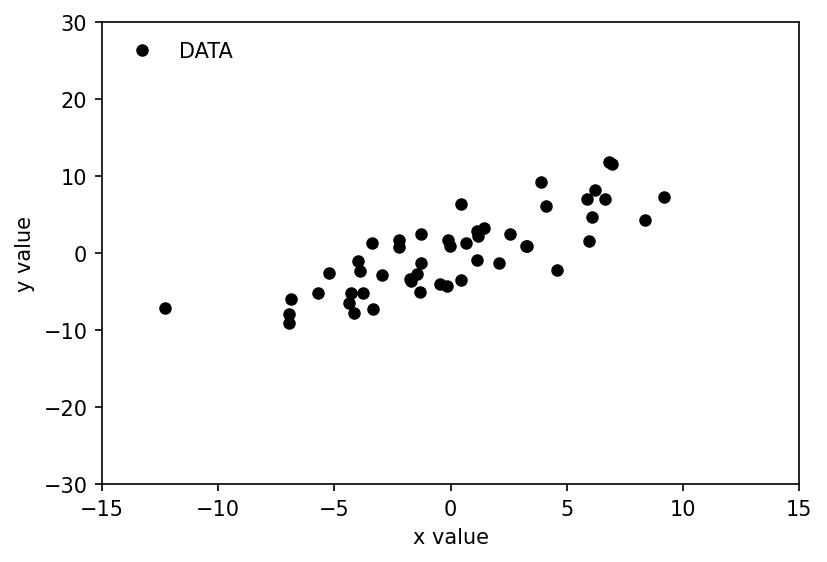

In [2]:
x = 5.0 * rng.standard_normal(50)
y = x + 5.0 + 3.0 * rng.standard_normal(len(x))

x = x - np.mean(x)
y = y - np.mean(y)

plt.figure()
plt.plot(x, y, "ok", markersize=5, label="DATA")
plt.xlabel("x value")
plt.ylabel("y value")
plt.xlim([-15, 15])
plt.ylim([-30, 30])
plt.legend(frameon=False, loc="upper left")
plt.show()


## Ordinary least squares: y vs x

Fit a line where `x` is independent and `y` is dependent.


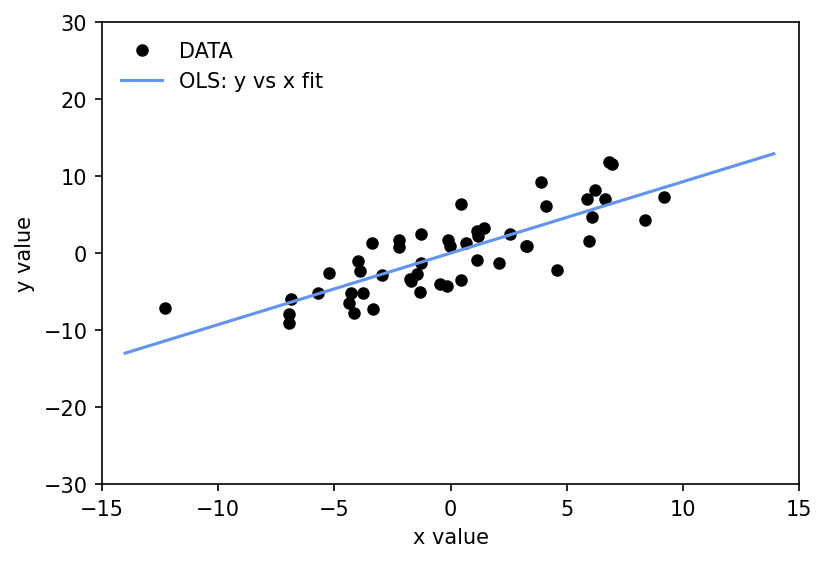

In [3]:
slope_yx, intercept_yx, r_yx, *_ = stats.linregress(x, y)

x_plot = np.arange(-14, 14, 0.1)

plt.figure()
plt.plot(x, y, "ok", markersize=5, label="DATA")
plt.plot(
    x_plot,
    intercept_yx + x_plot * slope_yx,
    "-",
    color="cornflowerblue",
    label="OLS: y vs x fit",
)
plt.xlabel("x value")
plt.ylabel("y value")
plt.xlim([-15, 15])
plt.ylim([-30, 30])
plt.legend(frameon=False, loc="upper left")
plt.show()


## What if we'd put `y` on the x-axis?

There's no a-priori reason to call `x` independent and `y` dependent. So fit the line the other way (`x` as a function of `y`), then invert the result so we can plot it on the same axes.


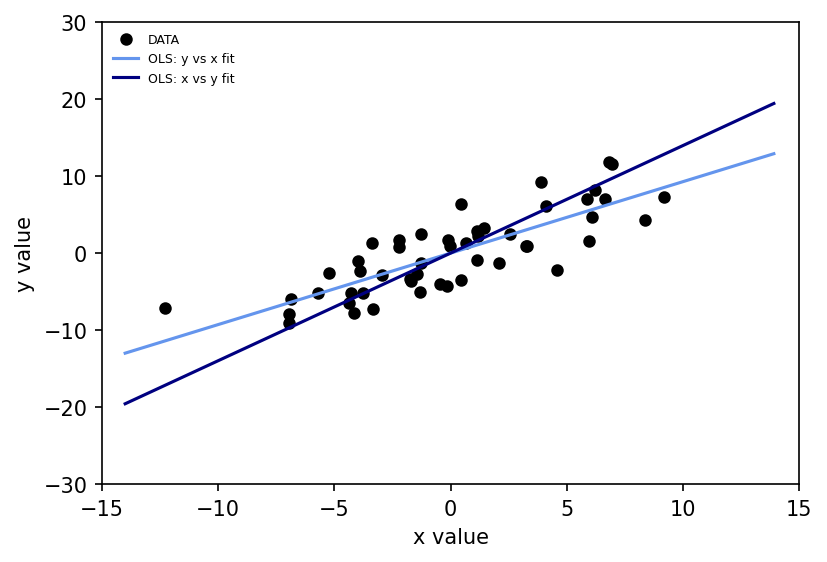

In [4]:
slope_xy, intercept_xy, *_ = stats.linregress(y, x)

plt.figure()
plt.plot(x, y, "ok", markersize=5, label="DATA")
plt.plot(
    x_plot,
    intercept_yx + x_plot * slope_yx,
    "-",
    color="cornflowerblue",
    label="OLS: y vs x fit",
)
plt.plot(
    x_plot,
    (1.0 / slope_xy) * x_plot - intercept_xy / slope_xy,
    "-",
    color="navy",
    label="OLS: x vs y fit",
)
plt.xlabel("x value")
plt.ylabel("y value")
plt.xlim([-15, 15])
plt.ylim([-30, 30])
plt.legend(frameon=False, loc="upper left", fontsize=6)
plt.show()


The two OLS lines **are not the same.** Your choice of which variable is independent matters because OLS minimizes the **vertical** error.

The cartoon below makes the geometry explicit: each blue segment is the vertical distance from a point to the line — the quantity OLS squares and sums.


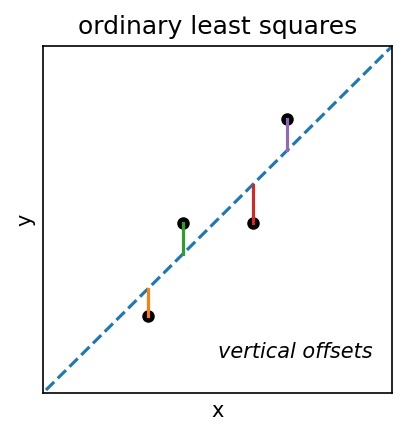

In [5]:
xvals = np.array([1, 2, 4, 5])
yvals = np.array([0.2, 2.9, 2.9, 5.9])
xplot = np.linspace(-15, 15, 100)

plt.figure(figsize=(3, 3))
plt.plot(xvals, yvals, "ok", markersize=5, label="data")
plt.plot(xplot, xplot, "--")
for xi, yi in zip(xvals, yvals):
    plt.plot([xi, xi], [yi, xi])

plt.xlim([-2, 8])
plt.ylim([-2, 8])
plt.gca().axes.xaxis.set_ticks([])
plt.gca().axes.yaxis.set_ticks([])
plt.title("ordinary least squares")
plt.xlabel("x")
plt.ylabel("y")
plt.text(3, -1, "vertical offsets", style="italic")
plt.show()


### Sanity check

If you standardize `x` and `y` (subtract mean, divide by std), the OLS slope of `y` on `x` equals `corr(x, y)`, and `1 / slope(y on x)` is `corr / 1` only when the variances match. Here we just look at the raw numbers.


In [6]:
slope_yx, *_ = stats.linregress(x, y)
slope_xy, *_ = stats.linregress(y, x)
print(f"corr(x, y)        = {np.corrcoef(x, y)[0, 1]:.4f}")
print(f"slope(y on x)     = {slope_yx:.4f}")
print(f"slope(x on y)     = {slope_xy:.4f}")
print(f"1 / slope(x on y) = {1.0 / slope_xy:.4f}")


corr(x, y)        = 0.8150
slope(y on x)     = 0.9284
slope(x on y)     = 0.7154
1 / slope(x on y) = 1.3978


## Orthogonal least squares (OLSQ)

OLSQ minimizes the **perpendicular** distance from each point to the line. Swapping `x` and `y` no longer changes the answer.

The OLSQ line is the major axis of the data cloud — equivalently, the eigenvector of the covariance matrix corresponding to the larger eigenvalue.


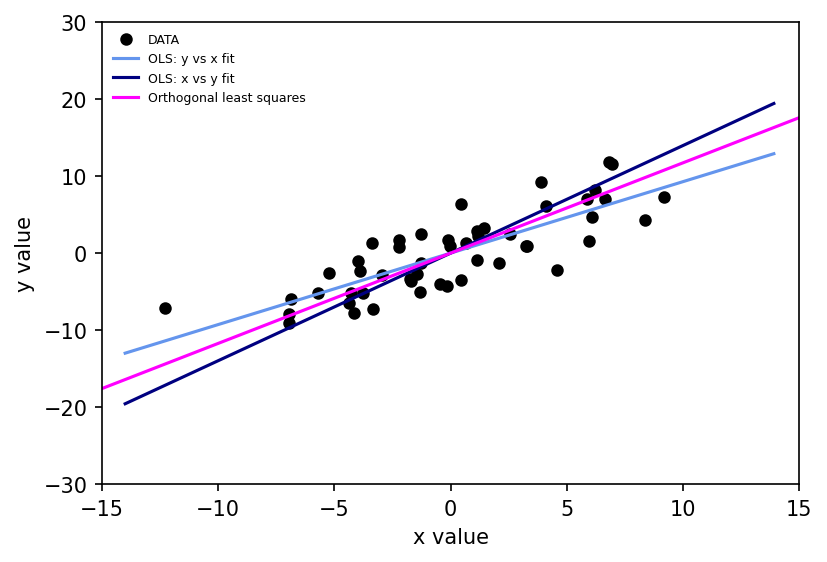

In [7]:
C = np.cov(np.vstack([x, y]))
eigvals, eigvecs = LA.eig(C)

# The eigenvector with the largest eigenvalue points along the OLSQ line.
i_max = int(np.argmax(eigvals))
v = eigvecs[:, i_max]

plt.figure()
plt.plot(x, y, "ok", markersize=5, label="DATA")
plt.plot(
    x_plot,
    intercept_yx + x_plot * slope_yx,
    "-",
    color="cornflowerblue",
    label="OLS: y vs x fit",
)
plt.plot(
    x_plot,
    (1.0 / slope_xy) * x_plot - intercept_xy / slope_xy,
    "-",
    color="navy",
    label="OLS: x vs y fit",
)
plt.plot(
    np.array([-v[0], v[0]]) * 30.0,
    np.array([-v[1], v[1]]) * 30.0,
    "-",
    color="fuchsia",
    label="Orthogonal least squares",
)
plt.xlabel("x value")
plt.ylabel("y value")
plt.xlim([-15, 15])
plt.ylim([-30, 30])
plt.legend(frameon=False, loc="upper left", fontsize=6)
plt.show()


If you don't have a good reason to single out one variable as independent, prefer OLSQ.

### Cartoon: perpendicular offsets

Same four points as before, but now the residuals are the perpendicular distances.


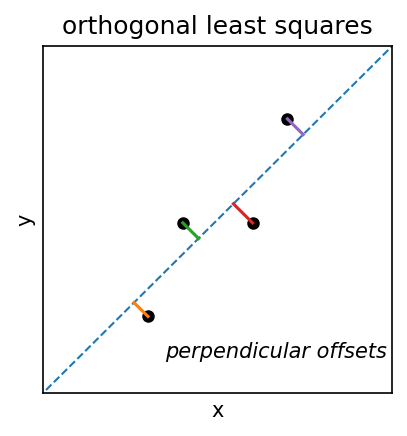

In [8]:
offsets = [(-0.4, 0.4), (0.45, -0.45), (-0.55, 0.55), (0.45, -0.45)]

plt.figure(figsize=(3, 3))
plt.plot(xvals, yvals, "ok", markersize=5, label="data")
plt.plot(xplot, xplot, "--", linewidth=1)
for (xi, yi), (dx, dy) in zip(zip(xvals, yvals), offsets):
    plt.plot([xi, xi + dx], [yi, yi + dy])

plt.xlim([-2, 8])
plt.ylim([-2, 8])
plt.gca().axes.xaxis.set_ticks([])
plt.gca().axes.yaxis.set_ticks([])
plt.title("orthogonal least squares")
plt.xlabel("x")
plt.ylabel("y")
plt.text(1.5, -1, "perpendicular offsets", style="italic")
plt.show()


## Wrap-up

- OLS minimizes vertical residuals. This means that the line you get depends on which variable you call dependent.
- OLSQ minimizes perpendicular residuals and so is symmetric in `x` and `y`.
- OLSQ aligns with the leading eigenvector of the data covariance matrix.
- Use OLSQ when neither variable has a privileged role; use OLS when there is a genuine predictor / response asymmetry.
